<a href="https://colab.research.google.com/github/Mohammed-Abu-Oudah/Predication-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title: Prediction of Product Sales
- Author: Mohammed Farid AbuOwda

## Project Overview

##Load and Inspect Data

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv'
sales_df = pd.read_csv(fpath)

In [ ]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
sales_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


##Clean Data

In [ ]:
# How many rows
print(len(sales_df))
# How many columns
print(len(sales_df.columns))

8523
12


In [ ]:
sales_df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [ ]:
# Are there any Duplicates? No
sales_df.duplicated().sum()

np.int64(0)

In [ ]:
# Identify Missing Values.
sales_df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [ ]:
sales_df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [ ]:
# Fill missing values with placeholders.
sales_df['Item_Weight'] = sales_df['Item_Weight'].fillna(-1)
print(f'number of missing values in item weight {sales_df['Item_Weight'].isna().sum()}')
sales_df['Outlet_Size'] = sales_df['Outlet_Size'].fillna('MISSING')
print(f'number of missing values in outlet size {sales_df['Outlet_Size'].isna().sum()}')

number of missing values in item weight 0
number of missing values in outlet size 0


<Axes: >

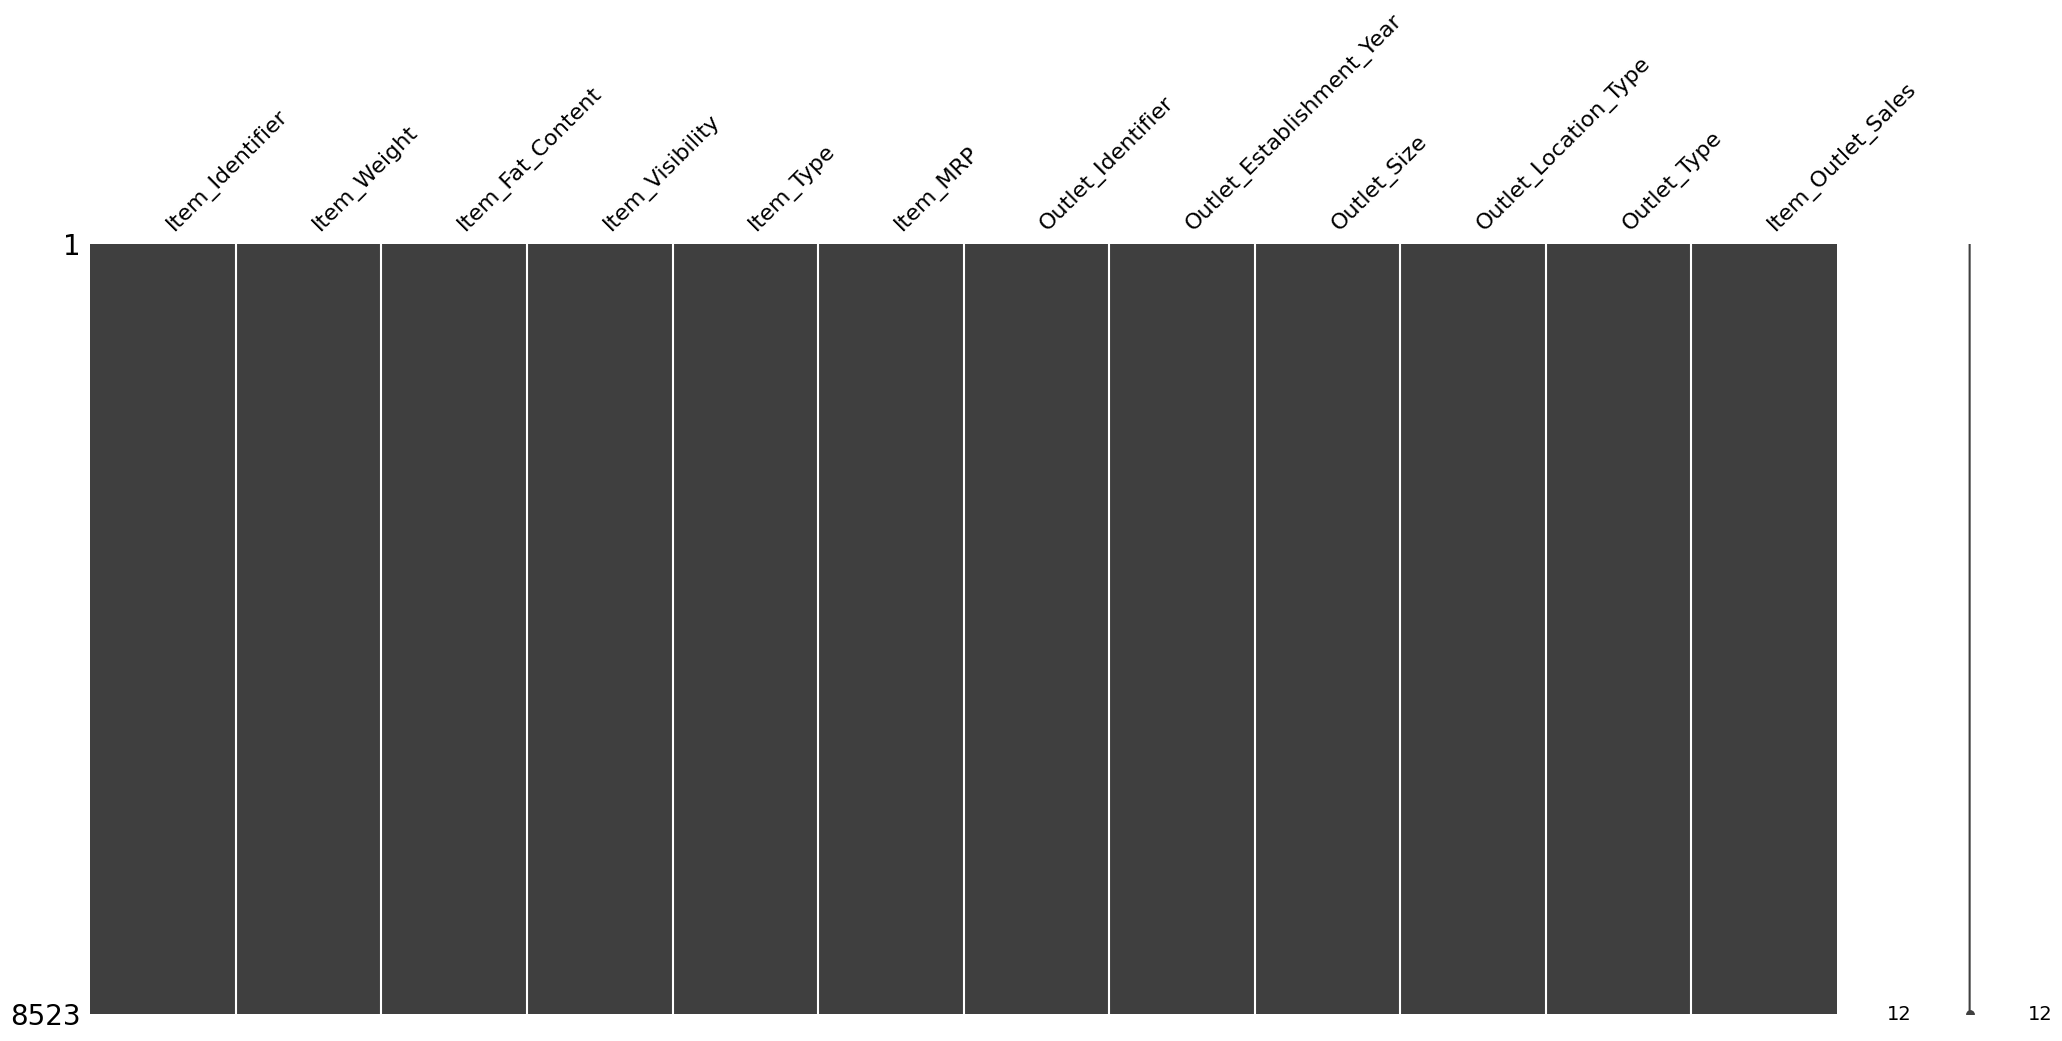

In [ ]:
import missingno as msno
msno.matrix(sales_df)

In [ ]:
# Fix inconsistant data: first we need to check if any inconsistant data exist
cat_columns = sales_df.select_dtypes('object')
for column in cat_columns:
  print(sales_df[column].value_counts())
  print("\n")

Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: cou

In [ ]:
# We can notice that in the Item_Fat_Content we find an inconsistent data in both low fat and regular
sales_df['Item_Fat_Content'] = sales_df['Item_Fat_Content'].replace({"LF" : "Low Fat", "low fat" : "Low Fat", "reg": "Regular"})
sales_df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [ ]:
sales_df.describe().round()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.0,8523.0,8523.0,8523.0,8523.0
mean,10.0,0.0,141.0,1998.0,2181.0
std,7.0,0.0,62.0,8.0,1706.0
min,-1.0,0.0,31.0,1985.0,33.0
25%,7.0,0.0,94.0,1987.0,834.0
50%,11.0,0.0,143.0,1999.0,1794.0
75%,16.0,0.0,186.0,2004.0,3101.0
max,21.0,0.0,267.0,2009.0,13087.0


##Exploratory Data Analysis

##Feature Inspection

**Now let's visualize the to understand the different relations**

In [ ]:
# First, get the info to show the features we need to work on
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
# Ok now lets descibe the numerical data using Histograms
# First let's list the numerical columns
numeric_cols = sales_df.select_dtypes('number').columns.tolist()
numeric_cols

['Item_Weight',
 'Item_Visibility',
 'Item_MRP',
 'Outlet_Establishment_Year',
 'Item_Outlet_Sales']

In [ ]:
# Ok, so for every one of the above, we will draw the histogram to understand the distribution of the data.
# But first let's import the seaborn and matplotlib libraries
import seaborn as sns
import matplotlib.pyplot as plt

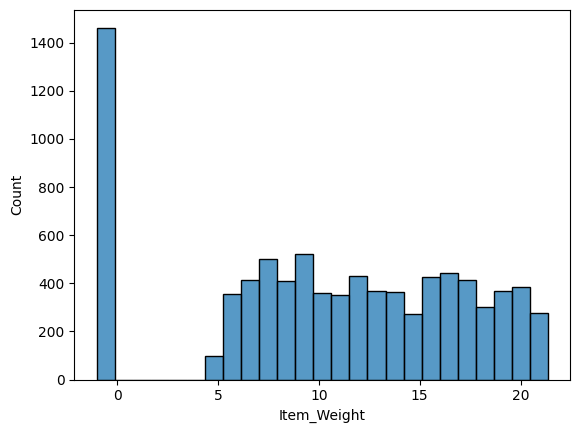

In [ ]:
# Print the historgram for Item_Weight
sns.histplot(data=sales_df, x='Item_Weight');

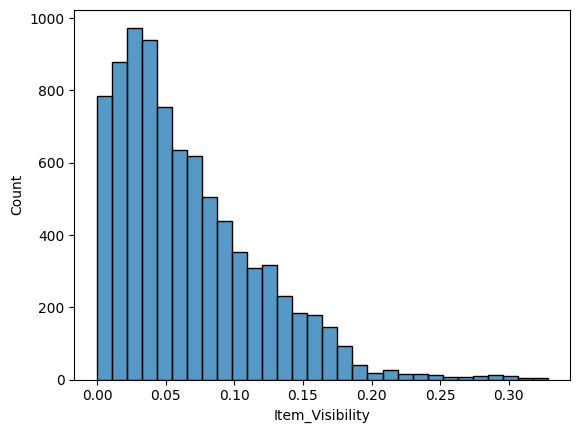

In [ ]:
# We can notice that the highest number of weights is -1 due to us replacing the Nan value with -1
# Now let's move on to the Item_Visibility column
sns.histplot(data=sales_df, x='Item_Visibility', bins=30);

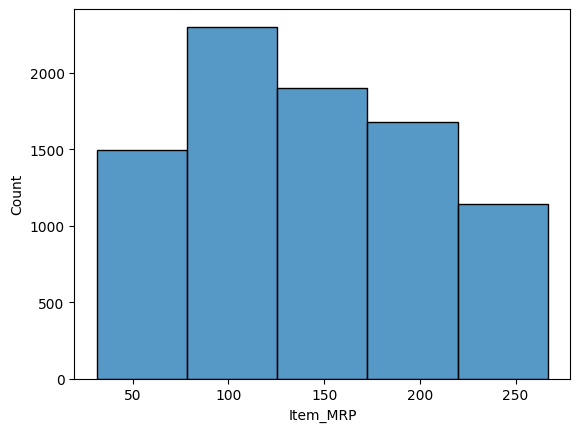

In [ ]:
# We can notice that the Item_Visibility doesn't follow a normal distribution (it is right skewed)
# Now let's plot the Item_MRP column
sns.histplot(data=sales_df, x='Item_MRP', bins=5);

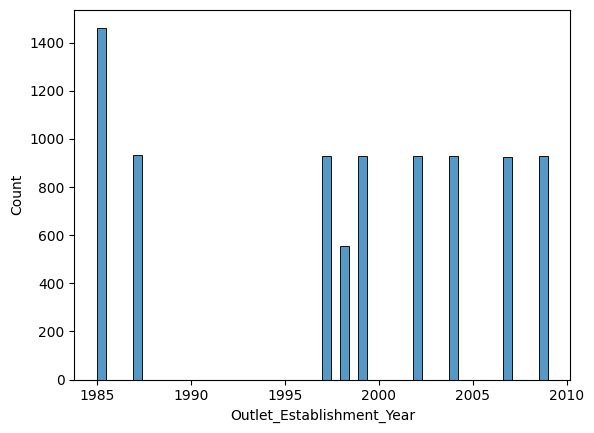

In [ ]:
# We can notic that the Item_MRP data doesn't have a specific pattern for the data distribution with a big number of bins but starts to follow right skewed Gaussian ditribution
# when reducing the number of bins.
# Now let's move to the Outlet_Establishment_Year column
sns.histplot(data=sales_df, x='Outlet_Establishment_Year', bins=50);

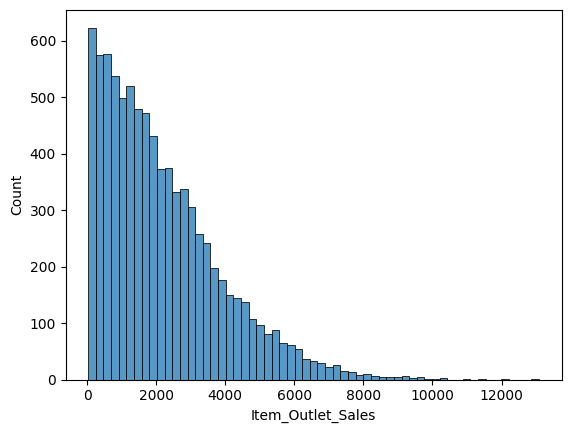

In [ ]:
# We can notice that most of the outlet's were established between years 1998 and 2000 and years 1985 and 1987
# And with the number of bins reduced, the data doesn't follow any Gaussian distribution.
# When increasing th number of bins we can notice that the highest number of outlets established - was in year 1985 - 1986
# that could be to the fact that in this period, the transition from small grocery to the big supermarkets and the big supermaket brands started to show up.
# Now let's move the Item_Outlet_Sales column
sns.histplot(data=sales_df, x='Item_Outlet_Sales');

In [ ]:
# We can notice that the Item_Outlet_Sales follow a right skewed Gaussian distribution
# most of the Item_Outlet_Sales are concentrated bewteen 0 and 2000, that could be to the fact that we might have a big number of small super markets emerging.
# Ok now let's move on to draw box plots for our numeric data
# same order as before but this time we will plot some boxplots
numeric_cols

['Item_Weight',
 'Item_Visibility',
 'Item_MRP',
 'Outlet_Establishment_Year',
 'Item_Outlet_Sales']

In [ ]:
# To save time we can just plot all the box plots in one plot to get an over new of the columns that has outliers
numeric_df = sales_df.select_dtypes('number')
numeric_df

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
0,9.300,0.016047,249.8092,1999,3735.1380
1,5.920,0.019278,48.2692,2009,443.4228
2,17.500,0.016760,141.6180,1999,2097.2700
3,19.200,0.000000,182.0950,1998,732.3800
4,8.930,0.000000,53.8614,1987,994.7052
...,...,...,...,...,...
8518,6.865,0.056783,214.5218,1987,2778.3834
8519,8.380,0.046982,108.1570,2002,549.2850
8520,10.600,0.035186,85.1224,2004,1193.1136
8521,7.210,0.145221,103.1332,2009,1845.5976


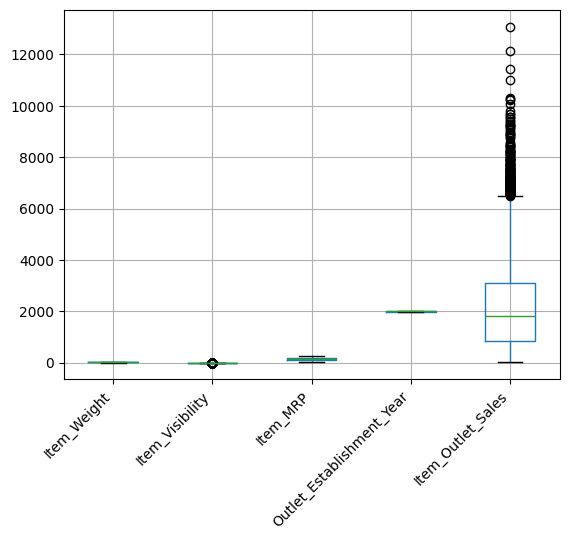

In [ ]:
fig, ax = plt.subplots()
ax = numeric_df.boxplot()
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

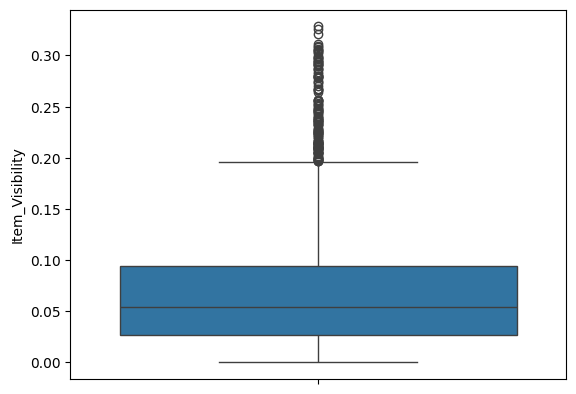

In [ ]:
# Both Item_Visiblity and Item_Outlet_Sales have outliers, for that we will try to draw them on a seperate plots
# Now let's draw the Item_Visiblity
sns.boxplot(sales_df, y='Item_Visibility');

<Axes: ylabel='Item_Outlet_Sales'>

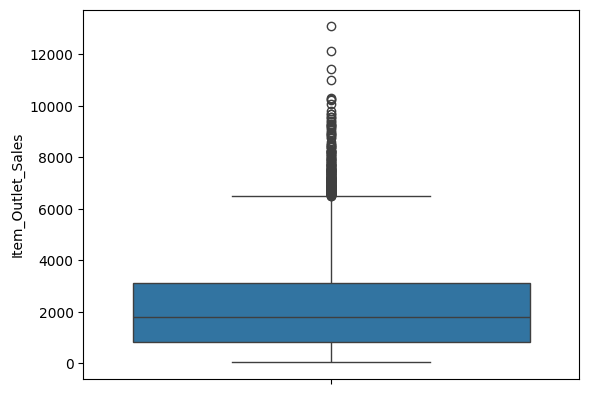

In [ ]:
# We can notice that the item visibility has a segnificant number of outliers, this could be due the way of shelfing the products.
# Now let's move to the Item_Outlet_Sales boxplot
sns.boxplot(data=sales_df, y='Item_Outlet_Sales')

In [ ]:
# We can also see that the Item_Outlet_Sales has a segnificant number of outliers due to the facts that some of these items exist in big and famous markets, and some good are consumed more than others.

<Axes: >

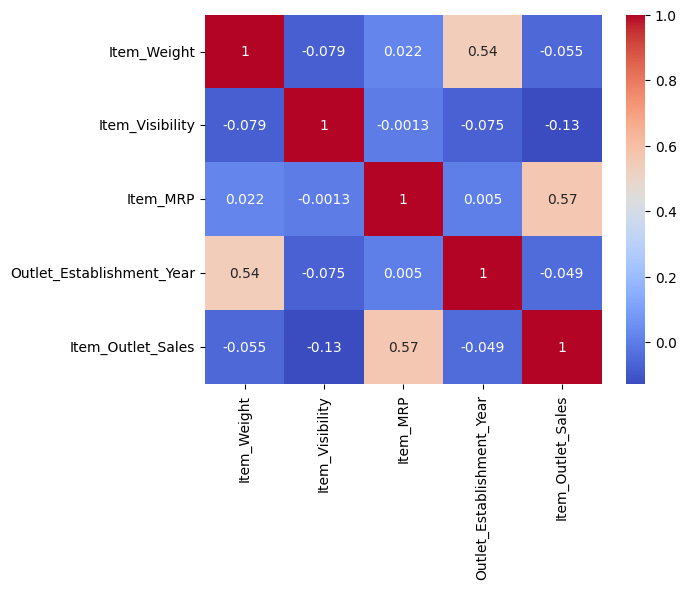

In [ ]:
# Now befor moving to the categorical columns, let's draw a heatmap of the numeric columns
corr = sales_df.corr(numeric_only=True)
sns.heatmap(data=corr, cmap='coolwarm', annot=True)

In [ ]:
# We can notic an intermediate relationship between (item weight, outlet establishment year) and (outlet establishment year, item MRP) couples.

**Now let's work with the categorical data**

In [ ]:
# First we will extract the columns of the categorical data
cat_columns.columns.tolist()

['Item_Identifier',
 'Item_Fat_Content',
 'Item_Type',
 'Outlet_Identifier',
 'Outlet_Size',
 'Outlet_Location_Type',
 'Outlet_Type']

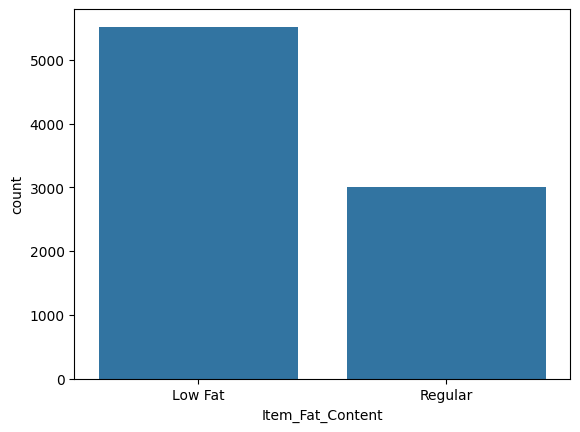

In [ ]:
# First Item_Identifier, we can't make count plot for that due to the huge number of items out there.
# Second Item_Fat_Content
sns.countplot(data=sales_df, x='Item_Fat_Content');

/tmp/ipykernel_1642/1051979962.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');


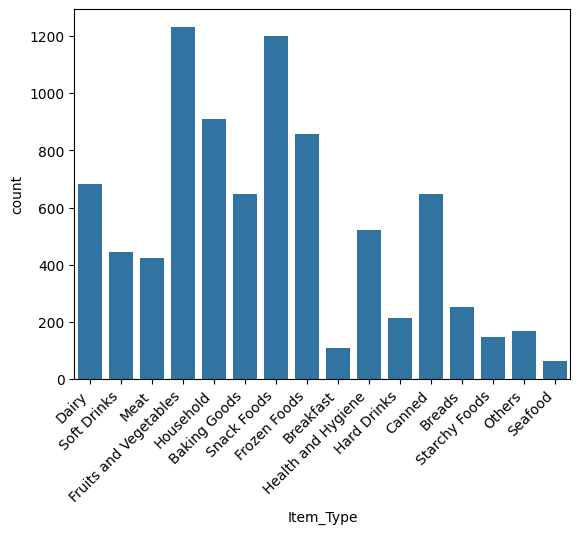

In [ ]:
# We can notice that the Items with low fats have higher counts the regular.
# Third Item_Type
ax = sns.countplot(data=sales_df, x='Item_Type');
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

/tmp/ipykernel_1642/2138505694.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');


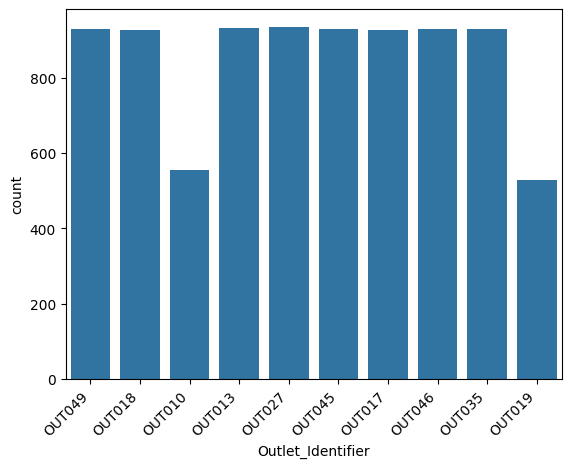

In [ ]:
# The Fruits and Vegetables are the items with the highest number of sales.
# now Outlet_Identifier has now meaning to graph the countplot for, but we will keep it in case we wanted to see how much did a specific outlet got repeated.
ax = sns.countplot(data=sales_df, x='Outlet_Identifier');
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

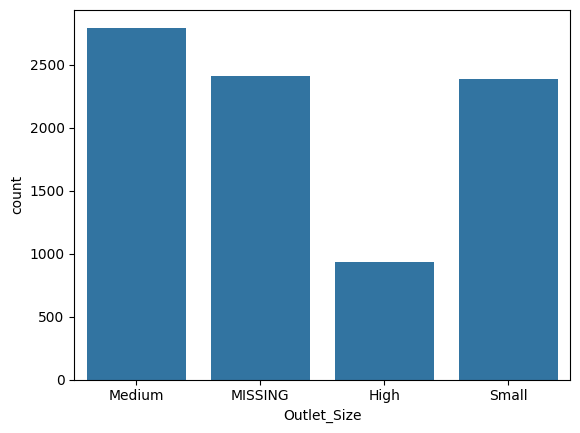

In [ ]:
# Now let's draw the countplot for Outlet_Size
ax = sns.countplot(data=sales_df, x='Outlet_Size');

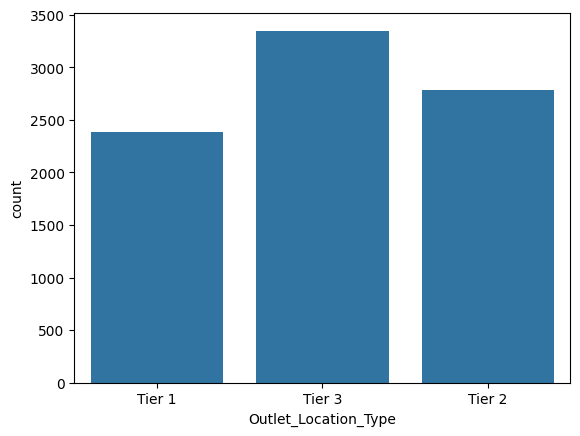

In [ ]:
# We can notice that the highest number of outlets are the medium ones.
# Now let's go for Outlet_Location_Type
ax = sns.countplot(data=sales_df, x='Outlet_Location_Type');

/tmp/ipykernel_1642/3509958554.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');


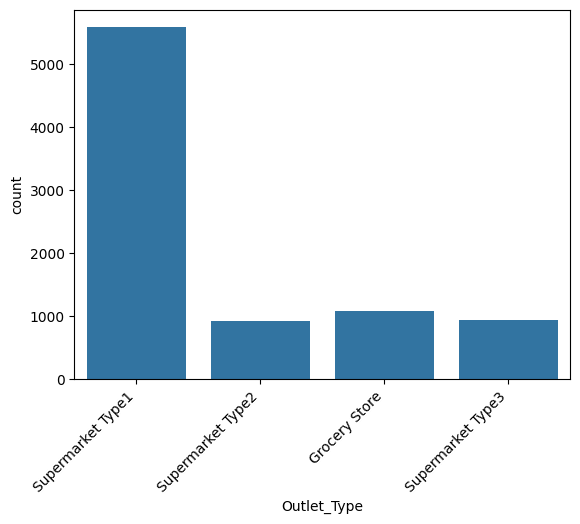

In [ ]:
# The highest number of the outlet location type is 'Tier 3'
# Now Outlet_Type
ax = sns.countplot(data=sales_df, x='Outlet_Type');
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

In [ ]:
# the Outlet type with the highest number is Supermarket Type1

#### Now let's replace the 'MISSING' and '-1' values with np.nan

In [ ]:
import numpy as np

In [ ]:
sales_df['Item_Weight'] = sales_df['Item_Weight'].replace(-1, np.nan)

In [ ]:
sales_df['Outlet_Size'] = sales_df['Outlet_Size'].str.strip().replace('MISSING', np.nan)

In [ ]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


Now let's define the functions that are going to be used for the visulization and comparision.
- First, univariant plots

In [ ]:
# UNIVARIATE PLOTTING FUNCTIONS FOR EDA
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):
  """Creates a seaborn countplot with the option to temporarily fill missing values
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}", fontweight='bold')
  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")

  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100

  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax

In [ ]:
def explore_numeric(df, x, figsize=(6,5) ):
  """Creates a seaborn histplot and boxplot with a share x-axis,
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  Source:{PASTE IN FINAL LESSON LINK}
  """

  ## Save null value counts and percent for printing
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100


  ## Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])

  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])

  ## Adding a title
  axes[0].set_title(f"Column: {x}", fontweight='bold')

  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()
  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = df[x].nunique()
  print(f"- Unique Values: {nunique}")


  # Get the most most common value, its count as # and as %
  most_common_val_count = df[x].value_counts(dropna=False).head(1)
  most_common_val = most_common_val_count.index[0]
  freq = most_common_val_count.values[0]
  perc_most_common = freq / len(df) * 100

  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, axes

- Second, multivariant plots

In [ ]:
def plot_categorical_vs_target(df, x, y='Item_Outlet_Sales',figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None):
  """Plots a combination of a seaborn barplot of means combined with
  a seaborn stripplot to show the spread of the data.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)

  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)

    # Barplot
  sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  # Boxplot
  sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                order=order, hue_order=order, legend=False,
                edgecolor='white', linewidth=0.5,
                size=3,zorder=0)
  # Rotate xlabels
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}", fontweight='bold')
  fig.tight_layout()
  return fig, ax

In [ ]:
def plot_numeric_vs_target(df, x, y='Item_Outlet_Sales',
                           figsize=(6,4)):
  """Plots a seaborn regplot with Pearson's correlation (r) added
  to the title.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Calculate the correlation
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]

  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','linewidths':1,'alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws)

  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y} (r = {r})", fontweight='bold')

  # Make sure the plot is shown before the print statement
  plt.show()

  return fig, ax

In [ ]:
sales_df.head(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


Now for each of the numeric values, explore them with some visualizations and answer the following questions:
- What type of feature is it?
- How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? If impute, with what?)
- Is the feature constant or quasi-constant?
- What is the cardinality? Is it high (>10)?
- Would we know this feature before the target is determined?
- Is there a business case/understanding reason to exclude based on our business case?

In [ ]:
numeric_cols

['Item_Weight',
 'Item_Visibility',
 'Item_MRP',
 'Outlet_Establishment_Year',
 'Item_Outlet_Sales']

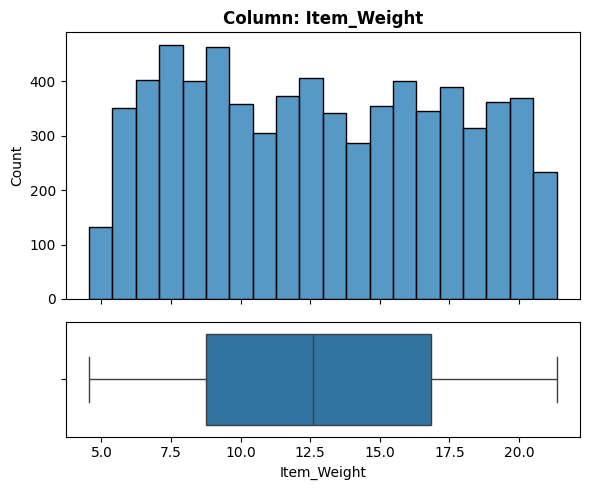

- NaN's Found: 1463 (17.17%)
- Unique Values: 415
- Most common value: 'nan' occurs 1463 times (17.17%)
- Not constant or quasi-constant.


(<Figure size 600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Column: Item_Weight'}, xlabel='Item_Weight', ylabel='Count'>,
        <Axes: xlabel='Item_Weight'>], dtype=object))

In [ ]:
explore_numeric(sales_df, x='Item_Weight')

- The feature is numeric.
- The number of null values is 1463, and the percentage is 17.17%, we will have to impute the null values, this could be done by the median of the weights grouped by the item type
- it's neither a constant or quasi-constant
- This is a numeric values, there's no meaning for cardinality here.
- yes
- No

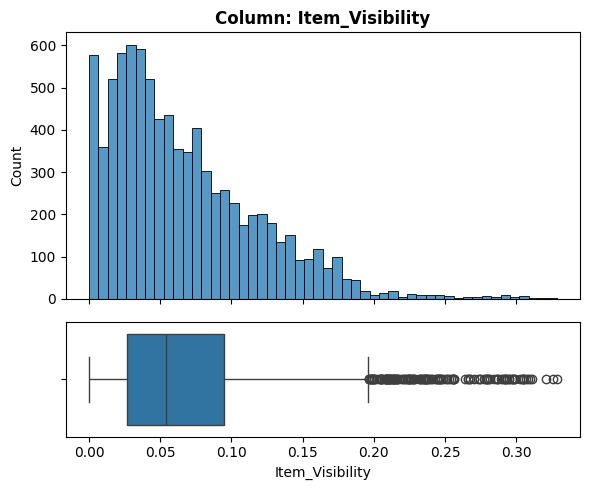

- NaN's Found: 0 (0.0%)
- Unique Values: 7880
- Most common value: '0.0' occurs 526 times (6.17%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(sales_df, x='Item_Visibility');

- The feature is numeric.
- The number of null values is 0, and the percentage is 0%
- it's neither a constant or quasi-constant
- This is a numeric values, there's no meaning for cardinality here.
- yes
- No

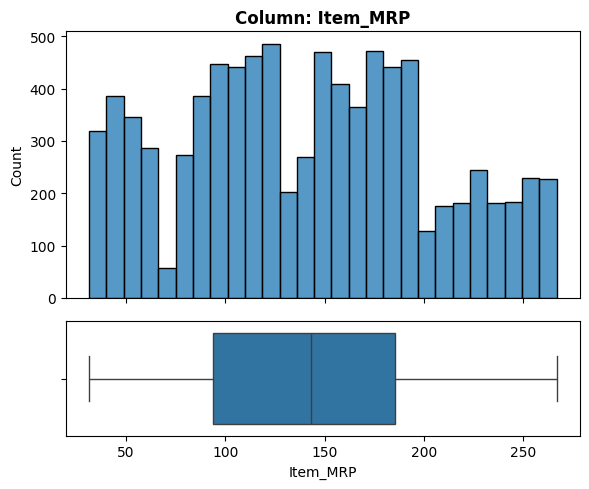

- NaN's Found: 0 (0.0%)
- Unique Values: 5938
- Most common value: '172.0422' occurs 7 times (0.08%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(sales_df, x='Item_MRP');

- The feature is numeric.
- The number of null values is 0, and the percentage is 0%
- it's neither a constant or quasi-constant
- This is a numeric values, there's no meaning for cardinality here.
- yes
- No

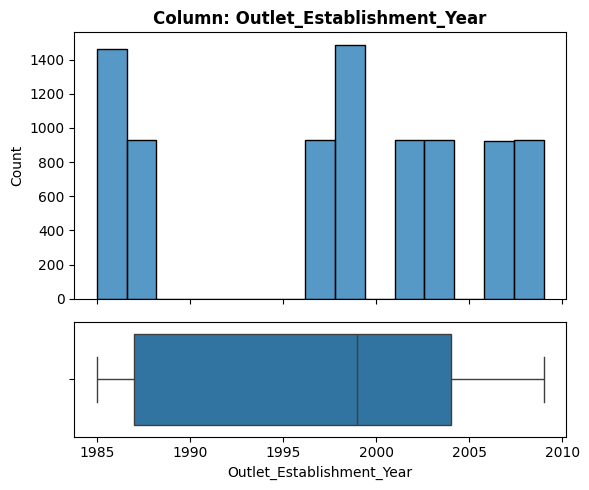

- NaN's Found: 0 (0.0%)
- Unique Values: 9
- Most common value: '1985' occurs 1463 times (17.17%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(sales_df, x='Outlet_Establishment_Year');

- The feature is numeric.
- The number of null values is 0, and the percentage is 0%
- it's neither a constant or quasi-constant
- This is a numeric values, there's no meaning for cardinality here.
- yes
- No

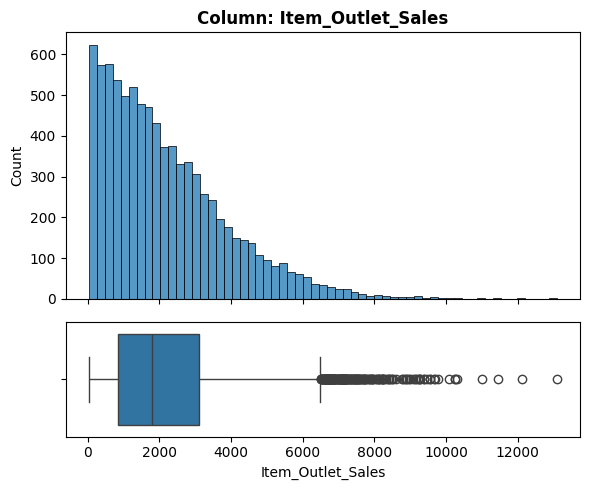

- NaN's Found: 0 (0.0%)
- Unique Values: 3493
- Most common value: '958.752' occurs 17 times (0.2%)
- Not constant or quasi-constant.


In [ ]:
explore_numeric(sales_df, x='Item_Outlet_Sales');

- The feature is numeric.
- The number of null values is 0, and the percentage is 0%
- it's neither a constant or quasi-constant
- This is a numeric values, there's no meaning for cardinality here.
- yes
- No

Now let's head for the categorical columns

In [ ]:
cat_columns

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDA15,Low Fat,Dairy,OUT049,Medium,Tier 1,Supermarket Type1
1,DRC01,Regular,Soft Drinks,OUT018,Medium,Tier 3,Supermarket Type2
2,FDN15,Low Fat,Meat,OUT049,Medium,Tier 1,Supermarket Type1
3,FDX07,Regular,Fruits and Vegetables,OUT010,MISSING,Tier 3,Grocery Store
4,NCD19,Low Fat,Household,OUT013,High,Tier 3,Supermarket Type1
...,...,...,...,...,...,...,...
8518,FDF22,Low Fat,Snack Foods,OUT013,High,Tier 3,Supermarket Type1
8519,FDS36,Regular,Baking Goods,OUT045,MISSING,Tier 2,Supermarket Type1
8520,NCJ29,Low Fat,Health and Hygiene,OUT035,Small,Tier 2,Supermarket Type1
8521,FDN46,Regular,Snack Foods,OUT018,Medium,Tier 3,Supermarket Type2


/tmp/ipykernel_1642/4216392884.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


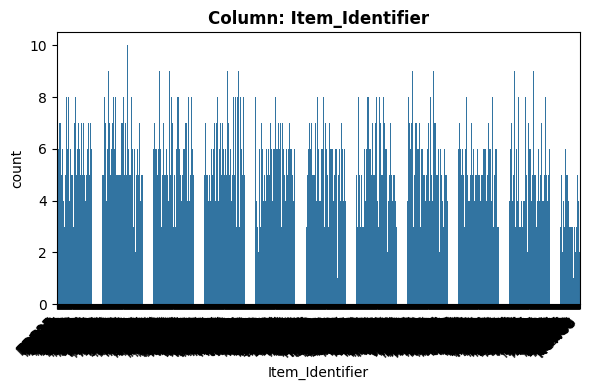

- NaN's Found: 0 (0.0%)
- Unique Values: 1559
- Most common value: 'FDW13' occurs 10 times (0.12%)
- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: Item_Identifier'}, xlabel='Item_Identifier', ylabel='count'>)

In [ ]:
explore_categorical(sales_df, x='Item_Identifier')

- The feature is catogrical.
- The number of null values is 0, and the percentage is 0%
- it's neither a constant or quasi-constant
- High cardinality
- yes
- Yes, we need to exclude this column, as it is just an identifier and won't have any affect on the results.

/tmp/ipykernel_1642/4216392884.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


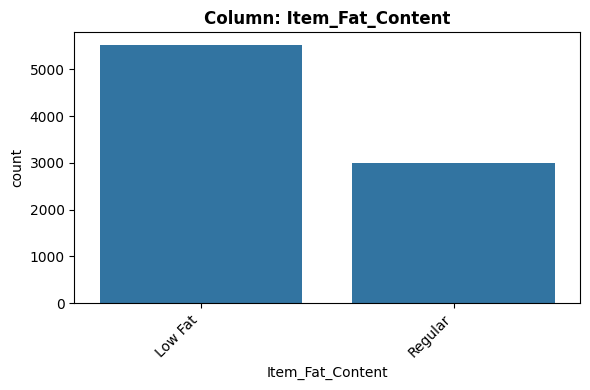

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'Low Fat' occurs 5517 times (64.73%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(sales_df, x='Item_Fat_Content');

- The feature is catogrical.
- The number of null values is 0, and the percentage is 0%
- it's neither a constant or quasi-constant
- low cardinality
- yes
- No

/tmp/ipykernel_1642/4216392884.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


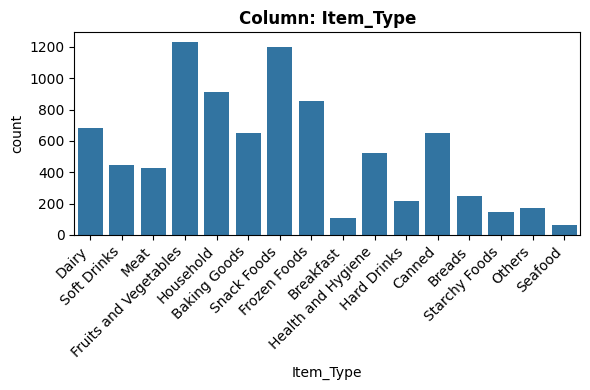

- NaN's Found: 0 (0.0%)
- Unique Values: 16
- Most common value: 'Fruits and Vegetables' occurs 1232 times (14.46%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(sales_df, x='Item_Type');

- The feature is catogrical.
- The number of null values is 0, and the percentage is 0%
- it's neither a constant or quasi-constant
- High cardinality
- yes
- No

/tmp/ipykernel_1642/4216392884.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


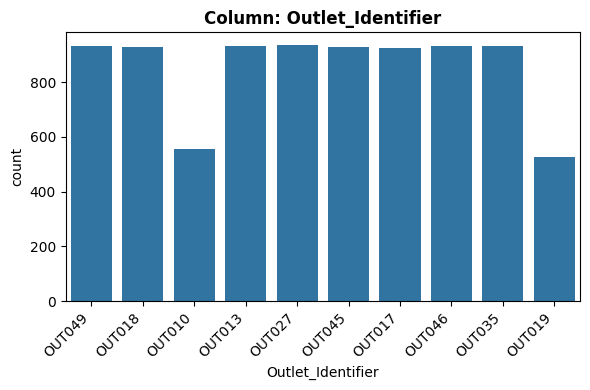

- NaN's Found: 0 (0.0%)
- Unique Values: 10
- Most common value: 'OUT027' occurs 935 times (10.97%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(sales_df, x='Outlet_Identifier');

- The feature is catogrical.
- The number of null values is 0, and the percentage is 0%
- it's neither a constant or quasi-constant
- regular cardinality
- yes
- Yes, we need to exclude this column, as it is just an identifier and won't have any affect on the results.

/tmp/ipykernel_1642/4216392884.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


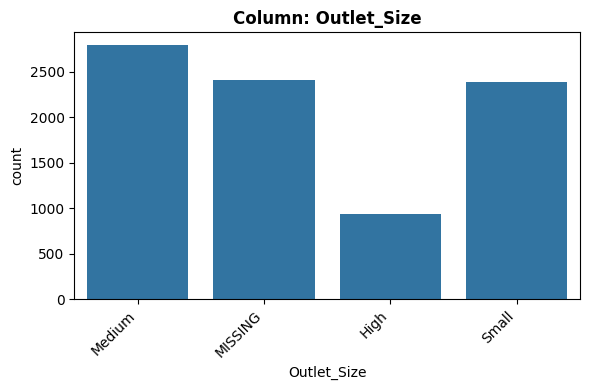

- NaN's Found: 2410 (28.28%)
- Unique Values: 4
- Most common value: 'Medium' occurs 2793 times (32.77%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(sales_df, x='Outlet_Size');

- The feature is catogrical.
- The number of null values is 2410, and the percentage is 28.28%, we need to impute the missing values, maybe by finding the mode of the values in the Outlet_size
- it's neither a constant or quasi-constant
- low cardinality
- yes
- No

/tmp/ipykernel_1642/4216392884.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


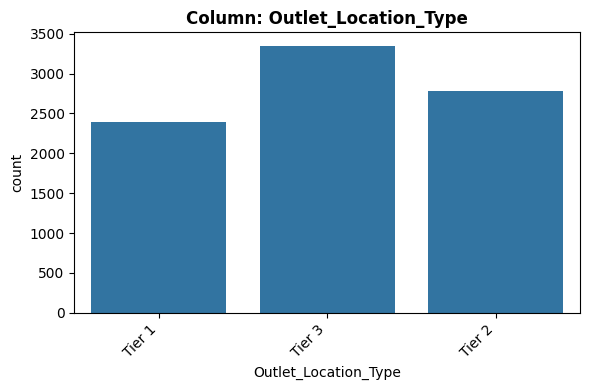

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: 'Tier 3' occurs 3350 times (39.31%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(sales_df, x='Outlet_Location_Type');

- The feature is catogrical.
- The number of null values is 0, and the percentage is 0%
- it's neither a constant or quasi-constant
- low cardinality
- yes
- No

/tmp/ipykernel_1642/4216392884.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


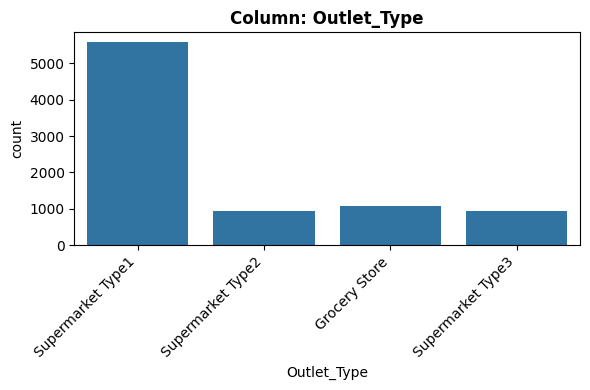

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: 'Supermarket Type1' occurs 5577 times (65.43%)
- Not constant or quasi-constant.


In [ ]:
explore_categorical(sales_df, x='Outlet_Type');

- The feature is catogrical.
- The number of null values is 0, and the percentage is 0%
- it's neither a constant or quasi-constant
- low cardinality
- yes
- No

In [ ]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
target_feature = 'Item_Outlet_Sales'

Now we will compare all the features to the target feature and answer the following questions:
- Based on your business understanding, would you expect this feature to be a predictor of the target?
- Does this feature appear to be a predictor of the target?

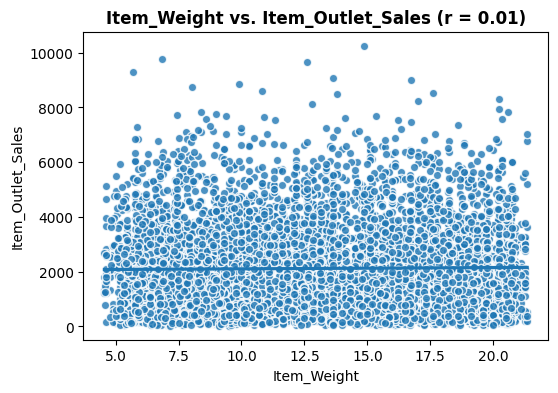

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Weight vs. Item_Outlet_Sales (r = 0.01)'}, xlabel='Item_Weight', ylabel='Item_Outlet_Sales'>)

In [ ]:
plot_numeric_vs_target(sales_df, x='Item_Weight')

- No
- No

/tmp/ipykernel_1642/3432662362.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Fat_Content vs. Item_Outlet_Sales'}, xlabel='Item_Fat_Content', ylabel='Item_Outlet_Sales'>)

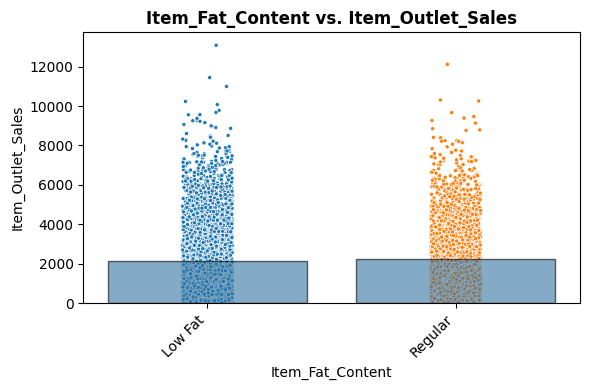

In [ ]:
plot_categorical_vs_target(sales_df, x='Item_Fat_Content')

- Yes
- No, no segnificant difference is present

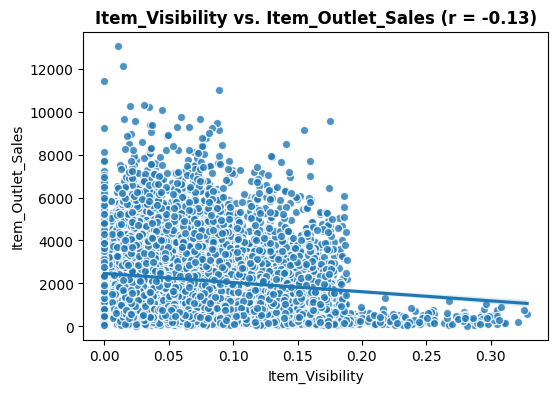

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Visibility vs. Item_Outlet_Sales (r = -0.13)'}, xlabel='Item_Visibility', ylabel='Item_Outlet_Sales'>)

In [ ]:
plot_numeric_vs_target(sales_df, x='Item_Visibility')

- Yes
- No, this seems like a negative correlation.

/tmp/ipykernel_1642/3432662362.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Type vs. Item_Outlet_Sales'}, xlabel='Item_Type', ylabel='Item_Outlet_Sales'>)

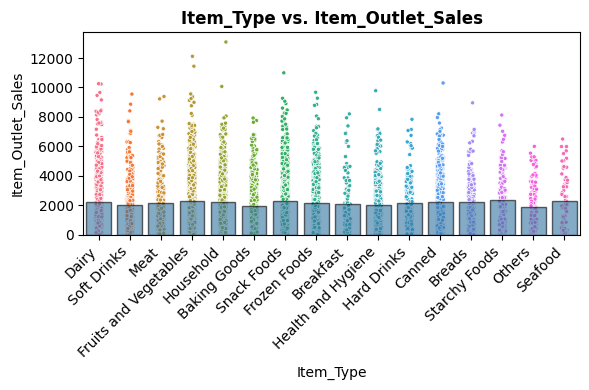

In [ ]:
plot_categorical_vs_target(sales_df, x='Item_Type')

- Yes.
- maybe, as I can notice that the Diary, Fruits and Vegetables, and starchy Foods have the highest means of sales.

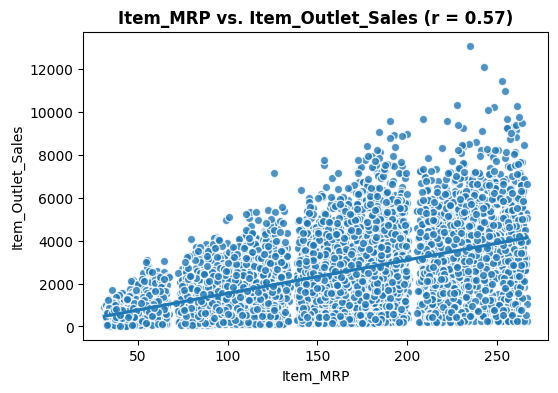

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_MRP vs. Item_Outlet_Sales (r = 0.57)'}, xlabel='Item_MRP', ylabel='Item_Outlet_Sales'>)

In [ ]:
plot_numeric_vs_target(sales_df, x='Item_MRP')

- Yes
- Yes

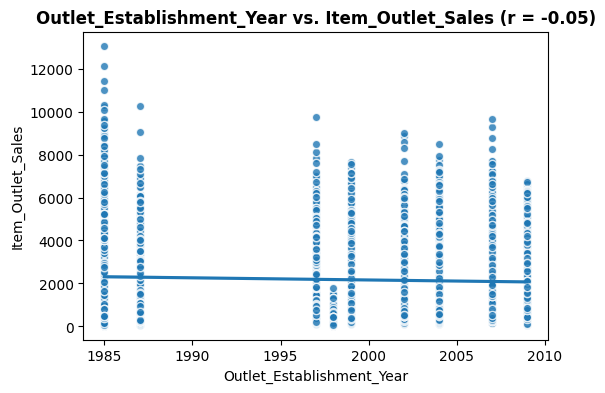

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Establishment_Year vs. Item_Outlet_Sales (r = -0.05)'}, xlabel='Outlet_Establishment_Year', ylabel='Item_Outlet_Sales'>)

In [ ]:
plot_numeric_vs_target(sales_df, x='Outlet_Establishment_Year')

- Yes
- No

/tmp/ipykernel_1642/3432662362.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Size vs. Item_Outlet_Sales'}, xlabel='Outlet_Size', ylabel='Item_Outlet_Sales'>)

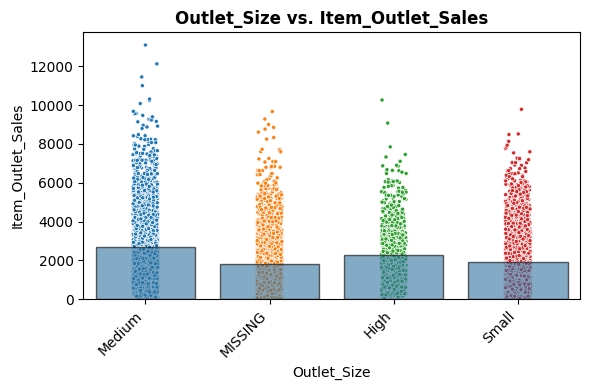

In [ ]:
plot_categorical_vs_target(sales_df, x='Outlet_Size')

- Yes
- maybe, as I can notice the the medium outlets have the the highest mean of sales, this could be due to the fact that most of the outlets are of a medium size.

/tmp/ipykernel_1642/3432662362.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Location_Type vs. Item_Outlet_Sales'}, xlabel='Outlet_Location_Type', ylabel='Item_Outlet_Sales'>)

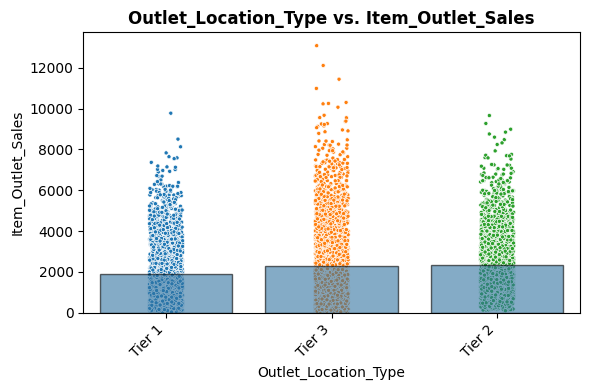

In [ ]:
plot_categorical_vs_target(sales_df, x='Outlet_Location_Type')

- No
- No

/tmp/ipykernel_1642/3432662362.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Type vs. Item_Outlet_Sales'}, xlabel='Outlet_Type', ylabel='Item_Outlet_Sales'>)

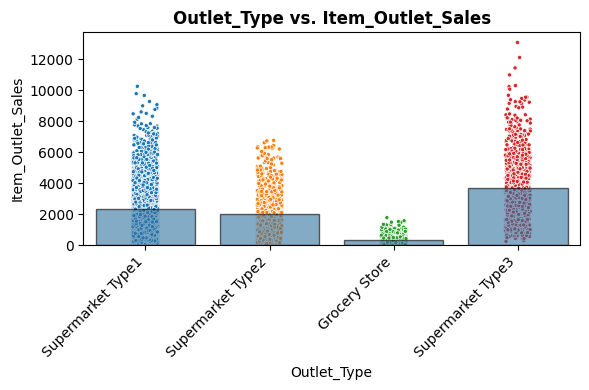

In [ ]:
plot_categorical_vs_target(sales_df, x='Outlet_Type')

- Yes
- Yes

## **And now the real work begins, we will train the prediction Model!**|

First we import the libraries

In [ ]:
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
y = sales_df['Item_Outlet_Sales']
X = sales_df.drop(columns=['Item_Outlet_Sales'], axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:
X_train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
4776,NCG06,16.350,Low Fat,0.029565,Household,256.4646,OUT018,2009,Medium,Tier 3,Supermarket Type2
7510,FDV57,15.250,Regular,0.000000,Snack Foods,179.7660,OUT018,2009,Medium,Tier 3,Supermarket Type2
5828,FDM27,12.350,Regular,0.158716,Meat,157.2946,OUT049,1999,Medium,Tier 1,Supermarket Type1
5327,FDG24,7.975,Low Fat,0.014628,Baking Goods,82.3250,OUT035,2004,Small,Tier 2,Supermarket Type1
4810,FDD05,19.350,Low Fat,0.016645,Frozen Foods,120.9098,OUT045,2002,NaN,Tier 2,Supermarket Type1


Numeric Pipeline

In [ ]:
# Now let's create the pipeline for the numeric values
numeric_cols = X_train.select_dtypes('number').columns
numeric_imputer = SimpleImputer(strategy='median')
numeric_scaler = StandardScaler()
numeric_pipe = make_pipeline(numeric_imputer, numeric_scaler)
numeric_tuple = ('numeric', numeric_pipe, numeric_cols)
numeric_tuple

('numeric',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                 ('standardscaler', StandardScaler())]),
 Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
        'Outlet_Establishment_Year'],
       dtype='object'))

In [ ]:
# Now let's create the pipeline for the ordinal columns
ordinal_cols = ['Outlet_Size']
ordinal_order = ['Small', 'Medium', 'High']
ordinal_categories = [ordinal_order]
ordinal_imputer = SimpleImputer(strategy='most_frequent')
ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)
ordinal_scaler = StandardScaler()
ordinal_pipe = make_pipeline(ordinal_imputer, ordinal_encoder, ordinal_scaler)
ordinal_tuple = ('ordinal', ordinal_pipe, ordinal_cols)
ordinal_tuple

('ordinal',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                 ('ordinalencoder',
                  OrdinalEncoder(categories=[['Small', 'Medium', 'High']])),
                 ('standardscaler', StandardScaler())]),
 ['Outlet_Size'])

In [ ]:
# Now let's create the pipeline for the categorical columns
cat_cols = X_train.select_dtypes('object').drop(columns=ordinal_cols).columns
# Now need for the imputer, as there are no null values in these columns
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_pipe = make_pipeline(ohe_encoder)
ohe_tuple = ('categorical', ohe_pipe, cat_cols)
ohe_tuple

('categorical',
 Pipeline(steps=[('onehotencoder',
                  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
 Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
        'Outlet_Location_Type', 'Outlet_Type'],
       dtype='object'))

Ok so to prevent data leakage and since we will train multiple models, we will use the columns transformer directly in the pipeline.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [ ]:
def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
  # Get metrics
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = root_mean_squared_error(y_true, y_pred)
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
    # Print Result with Label and Header
    header = "-"*60
    print(header, f"Regression Metrics: {label}", header, sep='\n')
    print(f"- MAE = {mae:,.3f}")
    print(f"- MSE = {mse:,.3f}")
    print(f"- RMSE = {rmse:,.3f}")
    print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
      metrics = {'Label':label, 'MAE':mae,
                 'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
      return metrics

def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True,
                        output_frame=False):
  # Get predictions for training data
  y_train_pred = reg.predict(X_train)

  # Call the helper function to obtain regression metrics for training data
  results_train = regression_metrics(y_train, y_train_pred, verbose = verbose,
                                     output_dict=output_frame,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = reg.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = regression_metrics(y_test, y_test_pred, verbose = verbose,
                                  output_dict=output_frame,
                                    label='Test Data' )

  # Store results in a dataframe if ouput_frame is True
  if output_frame:
    results_df = pd.DataFrame([results_train,results_test])
    # Set the label as the index
    results_df = results_df.set_index('Label')
    # Set index.name to none to get a cleaner looking result
    results_df.index.name=None
    # Return the dataframe
    return results_df.round(3)

In [ ]:
linear_regressor = LinearRegression()
linear_regressor_pipe = make_pipeline(ColumnTransformer([numeric_tuple, ordinal_tuple, ohe_tuple], verbose_feature_names_out=False), linear_regressor)
linear_regressor_pipe.fit(X_train, y_train)
evaluate_regression(linear_regressor_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 735.659
- MSE = 971,595.847
- RMSE = 985.696
- R^2 = 0.672

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 967.268
- MSE = 1,701,308.851
- RMSE = 1,304.342
- R^2 = 0.383


The model isn't overfitting or underfitting but the quality of the model is bad

Let's now try the random forest regression

In [ ]:
random_forest_regressor = RandomForestRegressor(random_state=42)
random_forest_pipe = make_pipeline(ColumnTransformer([numeric_tuple, ordinal_tuple, ohe_tuple], verbose_feature_names_out=False), random_forest_regressor)
random_forest_pipe.fit(X_train, y_train)
evaluate_regression(random_forest_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 297.575
- MSE = 184,522.563
- RMSE = 429.561
- R^2 = 0.938

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 772.301
- MSE = 1,238,114.851
- RMSE = 1,112.706
- R^2 = 0.551


This model is highly overfitting, hyperparameters tuning might help in this part

In this model the training results are better, but the testing results are still bad.

In [ ]:
params = {'randomforestregressor__max_depth': [None,10,15,20],
          'randomforestregressor__n_estimators':[10,100,150,200],
          }

In [ ]:
grid_search = GridSearchCV(random_forest_pipe, params, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                                                        ('ordinal',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          Si...
                                                                         Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object'))],
                                                          verbose_feature_names_out=False)),
                                       ('randomforestregressor',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'randomforestregressor__max_depth': [None, 10, 15, 20],
                         'randomforestregressor__n_estimators': [10, 100, 150,
                                                                 200]},
             verbose=1)

In [88]:
best_regression_forest = grid_search.best_estimator_
evaluate_regression(best_regression_forest, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 689.046
- MSE = 927,449.757
- RMSE = 963.042
- R^2 = 0.687

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 733.715
- MSE = 1,113,307.902
- RMSE = 1,055.134
- R^2 = 0.596


based on the final results, the best model so far the random forest regression model with the tuned hyperparameter.
The results are not very underfit, but the this is the one that provided the lowest blend of scores in both training and testing for the rmse and r2 results.

Based on the r2 results, we can obsereve that the features aren't the best features out there to describe the model's preformace, and the model can only perdict with a 0.589 accuracy.

For expressing to the stake holders we will focus on the test results and we will say the results deviate can deviate from the expected results by a range of ±(1100) units.

Because this metric is affected by the outliers which are very common thing in natural data, and if the outliers resulted in this huge rmse that means we didn't train the model on a well-imputed data that metigates the outliers.

The model is overfit, since the test score are worse than the training ones.